# 12. Phase 2 past window length — EDA (window sweep 학습 전 사전 진단)

**가설**: actual-anchored intraday update에서 정말로 긴 history가 추가 설명력을 주는가? 아니면 H=3 정도 짧은 window면 충분한가?

**측정 대상**: 최근 1~6h actual / residual feature가 *next 1h, 2h, 3h Phase 1 baseline의 |error|*를 얼마나 설명하는지.

**판정 기준**:
- |corr| > 0.20: 강한 신호 (window에 포함할 가치)
- 0.10~0.20: 약한 신호 (noise와 결합 시 도움 가능)
- < 0.10: 거의 noise

**Stratify**: overall / partial cloud (dc10Tca 3~7) / top cloud-pass events (2025-03-23 / 04-26 / 05-04).


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
import matplotlib as mpl, matplotlib.font_manager as fm
for f in ['Malgun Gothic','NanumGothic','AppleGothic']:
    if any(f.lower() in n.name.lower() for n in fm.fontManager.ttflist):
        mpl.rcParams['font.family'] = f; break
mpl.rcParams['axes.unicode_minus'] = False

ROOT = Path('../..').resolve()
SEEDS = [42, 123, 7, 202, 999]

# Phase 1 5-seed ensemble — both val (2024) and test (2025)
def load_p1(split):
    fname = f'{split}_predictions.parquet'
    dfs = [pd.read_parquet(ROOT / f'pv/experiments/resmlp_adaln_v2_ensemble/seed_{s}/{fname}').assign(seed=s)
           for s in SEEDS]
    a = pd.concat(dfs, ignore_index=True)
    g = a.groupby(['datetime_kst','site'])
    e = g.agg(cf=('cf','first'), cap=('site_capacity_kw','first'),
              mu_mean=('pred_mu','mean'),
              sigma_sq_mean=('pred_sigma', lambda s:(s**2).mean()),
              mu_var=('pred_mu','var')).reset_index()
    e['sigma_total'] = np.sqrt(e['sigma_sq_mean'] + e['mu_var'])
    e['datetime_kst'] = pd.to_datetime(e['datetime_kst'])
    return e

p1_test = load_p1('test')
print('test rows:', len(p1_test), ' | sites:', p1_test.site.nunique())
print('range:', p1_test.datetime_kst.min(), '~', p1_test.datetime_kst.max())

# weather (for partial cloud filter)
wx = pd.read_parquet(ROOT / 'data/processed/training_set.parquet')
wx['datetime_kst'] = pd.to_datetime(wx['datetime_kst'])
wx_keep = wx[['datetime_kst','site','dc10Tca','zenith_center']]
df = p1_test.merge(wx_keep, on=['datetime_kst','site'], how='left')
df = df.sort_values(['site','datetime_kst']).reset_index(drop=True)
df['hour']  = df.datetime_kst.dt.hour
df['date']  = df.datetime_kst.dt.normalize()
df['residual'] = df['cf'] - df['mu_mean']
print(f'merged: {len(df):,}')


test rows: 32443  | sites: 8
range: 2025-01-01 09:00:00 ~ 2025-12-31 17:00:00
merged: 32,443


## 1. Feature 생성 — 최근 K=1..6 시간의 actual / residual 정보

각 (site, datetime t)에서:
- `delta_kh` = `cf_t - cf_{t-k}` (k=1..6) — 최근 k시간 동안 actual cf 변화
- `resid_mean_kh` = mean of residual over [t-k+1, t] — 최근 k시간 평균 잔차 (Phase 1 over/under)
- `resid_std_3h`, `resid_std_6h` — 최근 변동성
- `drop_max_3h`, `drop_max_6h` — 최근 큰 하락 폭 (max negative cf delta)

**target**: `err_lead{1,2,3}` = `|cf_{t+lead} - mu_phase1_{t+lead}|` (Phase 1 absolute error at next K hours).


In [2]:
def add_lag_features(g):
    g = g.copy()
    for k in [1, 2, 3, 4, 5, 6]:
        g[f'delta_{k}h'] = g['cf'] - g['cf'].shift(k)
        g[f'resid_mean_{k}h'] = g['residual'].rolling(k, min_periods=1).mean().shift(0)
    g['resid_std_3h'] = g['residual'].rolling(3, min_periods=2).std()
    g['resid_std_6h'] = g['residual'].rolling(6, min_periods=2).std()
    # drop magnitude: 최근 K시간에서 가장 큰 하락 (negative delta of cf)
    for k in [3, 6]:
        cf_min_k = g['cf'].rolling(k, min_periods=1).min()
        g[f'drop_max_{k}h'] = g['cf'] - cf_min_k   # = how much cf is currently above min of last K
        # 더 직관적인 'last K 안 max drop' = max negative consecutive change
        g[f'drop_now_{k}h'] = g['cf'].diff().rolling(k, min_periods=1).apply(
            lambda x: -min(x.min(), 0) if len(x) > 0 else 0, raw=True)
    # next-K target absolute error
    for L in [1, 2, 3]:
        g[f'err_lead{L}'] = (g['cf'].shift(-L) - g['mu_mean'].shift(-L)).abs()
        g[f'cf_lead{L}']  = g['cf'].shift(-L)
        g[f'mu_lead{L}']  = g['mu_mean'].shift(-L)
        g[f'dc_lead{L}']  = g['dc10Tca'].shift(-L)
    return g

df = df.groupby('site', group_keys=False).apply(add_lag_features)
print('feature 추가 후:', df.shape)


feature 추가 후: (32443, 43)


C:\Users\brave\AppData\Local\Temp\ipykernel_25264\3830844117.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('site', group_keys=False).apply(add_lag_features)


## 2. ★ Correlation matrix — feature × |error at lead K|

각 feature가 next 1h, 2h, 3h |error|와 얼마나 상관 있는지. Daytime(zenith<60), 발행 가능한 시각에 한정.


In [3]:
issue = df[(df.zenith_center < 60) & (df.zenith_center.shift(-1) < 60) &
            (df['err_lead1'].notna())].copy()

LAG_FEATS = ['delta_1h','delta_2h','delta_3h','delta_4h','delta_5h','delta_6h',
             'resid_mean_1h','resid_mean_2h','resid_mean_3h','resid_mean_4h','resid_mean_5h','resid_mean_6h',
             'resid_std_3h','resid_std_6h','drop_now_3h','drop_now_6h']

def corr_table(d, label):
    rows = []
    for f in LAG_FEATS:
        sub = d[[f,'err_lead1','err_lead2','err_lead3']].dropna()
        if len(sub) < 100: continue
        r = {'feature': f, 'n': len(sub)}
        for L in [1,2,3]:
            r[f'|corr| L{L}h'] = sub[[f, f'err_lead{L}']].corr().iloc[0,1]
        rows.append(r)
    out = pd.DataFrame(rows).set_index('feature')
    print(f'\n=== {label} (n={len(d):,}) ===')
    print(out.round(3).to_string())
    return out

corr_overall = corr_table(issue, 'OVERALL (daytime)')



=== OVERALL (daytime) (n=15,662) ===
                   n  |corr| L1h  |corr| L2h  |corr| L3h
feature                                                 
delta_1h       15662      -0.088      -0.014       0.061
delta_2h       15662      -0.111      -0.019       0.068
delta_3h       15662      -0.109      -0.025       0.052
delta_4h       15657      -0.096      -0.036       0.007
delta_5h       15652      -0.082      -0.059      -0.050
delta_6h       15652      -0.074      -0.082      -0.095
resid_mean_1h  15662      -0.581      -0.465      -0.343
resid_mean_2h  15662      -0.560      -0.436      -0.311
resid_mean_3h  15662      -0.529      -0.402      -0.279
resid_mean_4h  15662      -0.503      -0.376      -0.257
resid_mean_5h  15662      -0.487      -0.364      -0.250
resid_mean_6h  15662      -0.479      -0.365      -0.259
resid_std_3h   15662       0.430       0.337       0.244
resid_std_6h   15662       0.578       0.439       0.314
drop_now_3h    15662       0.128       0.039      

→ **판독 기준**:
- |corr| > 0.20: ★ 강한 신호
- 0.10~0.20: 약함
- < 0.10: noise

**핵심 질문**: lag 5~6h feature가 lag 1~3h feature보다 |corr|이 *현저히 작은가*? 그렇다면 H=3~4로 충분.


## 3. Stratify — Partial cloud (target lead의 dc10Tca 3~7)


In [4]:
# partial cloud at target lead (lead 1h 기준 분류)
pc = issue[(issue['dc_lead1'] >= 3) & (issue['dc_lead1'] <= 7)].copy()
corr_pc = corr_table(pc, 'PARTIAL CLOUD (target dc 3~7)')



=== PARTIAL CLOUD (target dc 3~7) (n=4,676) ===
                  n  |corr| L1h  |corr| L2h  |corr| L3h
feature                                                
delta_1h       4676      -0.117      -0.043       0.041
delta_2h       4676      -0.169      -0.075       0.022
delta_3h       4676      -0.200      -0.109      -0.011
delta_4h       4676      -0.204      -0.140      -0.066
delta_5h       4676      -0.202      -0.173      -0.134
delta_6h       4676      -0.195      -0.203      -0.196
resid_mean_1h  4676      -0.609      -0.521      -0.412
resid_mean_2h  4676      -0.605      -0.504      -0.388
resid_mean_3h  4676      -0.587      -0.477      -0.357
resid_mean_4h  4676      -0.567      -0.453      -0.333
resid_mean_5h  4676      -0.555      -0.440      -0.323
resid_mean_6h  4676      -0.549      -0.441      -0.327
resid_std_3h   4676       0.352       0.287       0.219
resid_std_6h   4676       0.582       0.459       0.349
drop_now_3h    4676       0.043      -0.035      -0.108

## 4. Stratify — Top cloud-pass event days (3개 날짜)


In [5]:
events = pd.to_datetime(['2025-03-23','2025-04-26','2025-05-04'])
ev = issue[issue.date.isin(events)].copy()
corr_ev = corr_table(ev, 'TOP cloud-pass EVENTS')



=== TOP cloud-pass EVENTS (n=176) ===
                 n  |corr| L1h  |corr| L2h  |corr| L3h
feature                                               
delta_1h       176      -0.450      -0.240      -0.007
delta_2h       176      -0.529      -0.192       0.108
delta_3h       176      -0.461      -0.065       0.179
delta_4h       176      -0.310       0.013       0.165
delta_5h       176      -0.242      -0.040       0.052
delta_6h       176      -0.286      -0.186      -0.131
resid_mean_1h  176      -0.689      -0.285       0.017
resid_mean_2h  176      -0.554      -0.141       0.127
resid_mean_3h  176      -0.421      -0.029       0.192
resid_mean_4h  176      -0.325       0.031       0.227
resid_mean_5h  176      -0.281       0.058       0.242
resid_mean_6h  176      -0.262       0.068       0.242
resid_std_3h   176       0.430       0.226      -0.014
resid_std_6h   176       0.433       0.083      -0.142
drop_now_3h    176       0.552       0.217      -0.042
drop_now_6h    176       0

## 5. Lag별 신호 요약 — H=3 vs H=6 결정 근거


In [6]:
def best_per_lag(corr_df, segment_label):
    rows = []
    for L in [1,2,3]:
        col = f'|corr| L{L}h'
        if col not in corr_df.columns: continue
        d = corr_df[col].abs().sort_values(ascending=False)
        rows.append({'segment': segment_label, 'lead': f'{L}h',
                     'top1': d.index[0], 'top1_corr': d.iloc[0],
                     'top2': d.index[1], 'top2_corr': d.iloc[1],
                     'top3': d.index[2], 'top3_corr': d.iloc[2]})
    return pd.DataFrame(rows)

ranks = pd.concat([
    best_per_lag(corr_overall, 'overall'),
    best_per_lag(corr_pc, 'partial_cloud'),
    best_per_lag(corr_ev, 'top_events'),
], ignore_index=True)
print('\n=== Top-3 features per (segment, lead) ===')
print(ranks.round(3).to_string(index=False))



=== Top-3 features per (segment, lead) ===
      segment lead          top1  top1_corr          top2  top2_corr          top3  top3_corr
      overall   1h resid_mean_1h      0.581  resid_std_6h      0.578 resid_mean_2h      0.560
      overall   2h resid_mean_1h      0.465  resid_std_6h      0.439 resid_mean_2h      0.436
      overall   3h resid_mean_1h      0.343  resid_std_6h      0.314 resid_mean_2h      0.311
partial_cloud   1h resid_mean_1h      0.609 resid_mean_2h      0.605 resid_mean_3h      0.587
partial_cloud   2h resid_mean_1h      0.521 resid_mean_2h      0.504 resid_mean_3h      0.477
partial_cloud   3h resid_mean_1h      0.412 resid_mean_2h      0.388 resid_mean_3h      0.357
   top_events   1h resid_mean_1h      0.689 resid_mean_2h      0.554   drop_now_3h      0.552
   top_events   2h resid_mean_1h      0.285      delta_1h      0.240  resid_std_3h      0.226
   top_events   3h resid_mean_6h      0.242 resid_mean_5h      0.242 resid_mean_4h      0.227


## 6. lag k vs |corr| 곡선 (delta 시리즈만)

가장 명확한 시각화: `delta_1h, delta_2h, ..., delta_6h`의 |corr|가 k 증가할수록 어떻게 변하나.


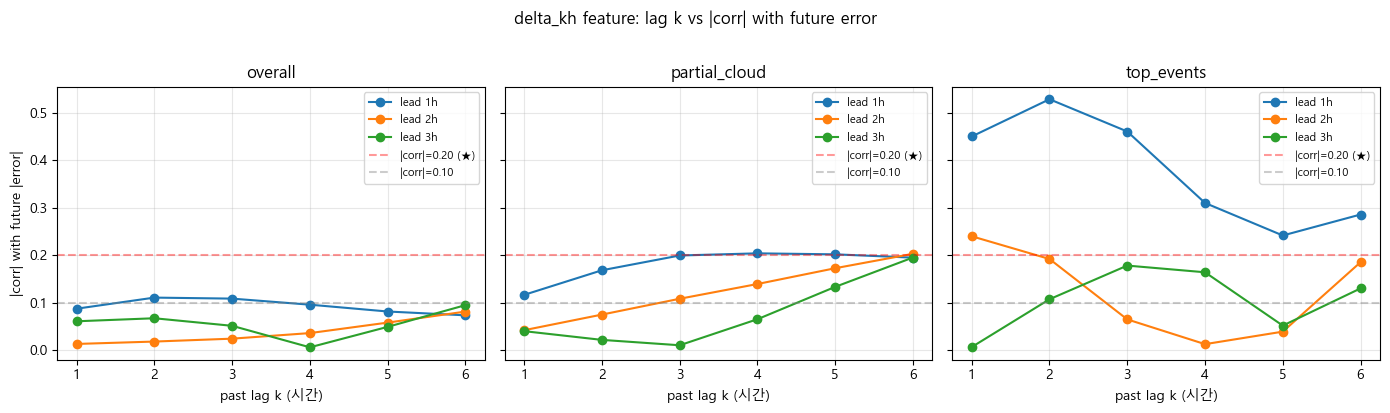

In [7]:
def lag_curve(corr_df, name):
    out = {}
    for L in [1,2,3]:
        c = corr_df[f'|corr| L{L}h'].abs()
        out[f'lead{L}'] = [c.get(f'delta_{k}h', np.nan) for k in [1,2,3,4,5,6]]
    return out

curves = {
    'overall': lag_curve(corr_overall, 'overall'),
    'partial_cloud': lag_curve(corr_pc, 'partial_cloud'),
    'top_events': lag_curve(corr_ev, 'top_events'),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (seg, c) in zip(axes, curves.items()):
    for L in [1,2,3]:
        ax.plot([1,2,3,4,5,6], c[f'lead{L}'], marker='o', label=f'lead {L}h')
    ax.set_title(seg)
    ax.set_xlabel('past lag k (시간)')
    ax.axhline(0.20, color='red', ls='--', alpha=0.4, label='|corr|=0.20 (★)')
    ax.axhline(0.10, color='gray', ls='--', alpha=0.4, label='|corr|=0.10')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('|corr| with future |error|')
plt.suptitle('delta_kh feature: lag k vs |corr| with future error', y=1.02)
plt.tight_layout(); plt.show()


→ **모델 함의**:
- 곡선이 k=3 이후 가파르게 감쇠 → **H=3** 이면 충분 (오래된 정보는 noise)
- 곡선이 k=6까지 평탄 → **H=6** 또는 더 길게 가는 게 합리
- segment마다 패턴 다름 → segment-aware window가 의미 있을 수 있음 (event에서만 long history 활용)


## 7. resid_mean / resid_std 측정

cf delta보다 *Phase 1 잔차 history*가 더 직접 신호일 수 있음 (Phase 2가 학습할 신호).


C:\Users\brave\AppData\Local\Temp\ipykernel_25264\1825834059.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rfeats, rotation=30, ha='right')


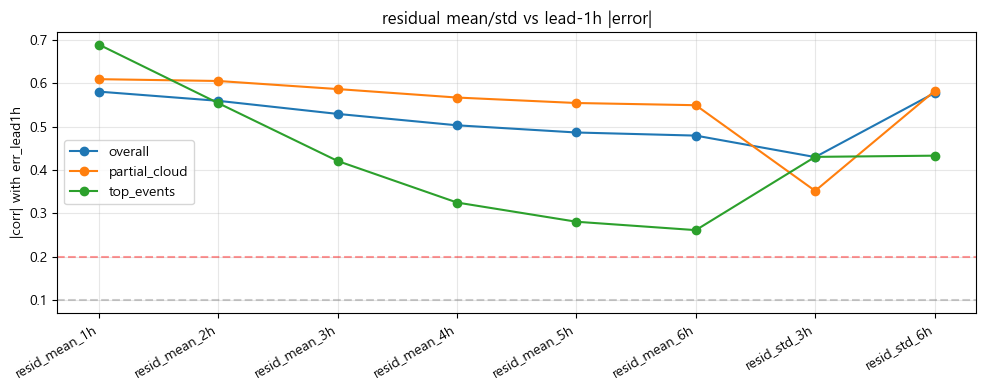

In [8]:
rfeats = [f'resid_mean_{k}h' for k in [1,2,3,4,5,6]] + ['resid_std_3h','resid_std_6h']
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for seg_name, seg_df in [('overall', issue), ('partial_cloud', pc), ('top_events', ev)]:
    vals = []
    for f in rfeats:
        sub = seg_df[[f,'err_lead1']].dropna()
        if len(sub) < 100:
            vals.append(np.nan); continue
        vals.append(sub[[f,'err_lead1']].corr().iloc[0,1])
    ax.plot(rfeats, [abs(v) for v in vals], marker='o', label=seg_name)
ax.axhline(0.20, color='red', ls='--', alpha=0.4)
ax.axhline(0.10, color='gray', ls='--', alpha=0.4)
ax.set_ylabel('|corr| with err_lead1h')
ax.set_xticklabels(rfeats, rotation=30, ha='right')
ax.set_title('residual mean/std vs lead-1h |error|')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


→ **모델 함의**: resid_mean이 cf delta보다 강한 신호면, Phase 2가 정말 학습하는 건 *Phase 1 잔차 패턴*이라는 의미. 약하면 actual cf 자체가 더 정보 있음.


## 8. 결론 분기

| 진단 | window 권장 | 학습 sweep 우선순위 |
|---|---|---|
| 모든 segment에서 lag k=3 이후 |corr| < 0.10 | **H=3 채택** | H=3, 4 비교만 (H=5,6 skip) |
| event에서만 lag k=4~6 |corr| > 0.15 | **segment-aware (현행 H=6 유지)** | H=4, 5, 6 비교 |
| lag k=4~5에서 plateau | **H=4 또는 H=5** | H=3, 4, 5 모두 비교 |
| 모든 lag |corr| < 0.10 | window 자체 의미 약함 | window sweep 폐기, 다른 가설 |

이 노트북 결과를 보고 다음 단계(window sweep) seed/H 조합 결정.
